## Title
Modelo Baseline
### By:
Dovaribi Carupia Yagari

### Date:
2026-08-21

### Description:

Crear un modelo base para tenerlo como referencia para luego comparar al entrenar modelos de machine learning, el modelo base puede ser un modelo de heurísticas o un [modelo dummy](https://scikit-learn.org/stable/api/sklearn.dummy.html). Crear un nuevo branch de git (Usar [Gitflow](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/)).

> Tomar como ejemplo los pasos de: <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/>

En este proceso se incluye :

- Usar pipeline de procesamiento de datos creado en la tarea anterior
- Dividir los datos en Train / Test
- Evaluar con diferentes métricas según el problema que se esta solucionando
- Usar validación cruzada (Cross validation) y obtener la media y la desviación estándar de la medida de las evoluciones realizadas.
- Seleccionar la variable mas importante y justificar por que se selecciona.
- Realizar el análisis de Learning curve
- Obtener las gráficas de escalabilidad con tiempo de entrenamiento y score
- Interpretar los resultados
- Realizar análisis de los resultados
- Realizar conclusiones
- Definir recomendaciones para crear un modelo en base a los resultados del modelo base
- Proponer ideas en base a los resultados obtenidos

> Puede utilizar las librerías o herramientas que considere para resolver la tarea

# Entregables

Notebook con la descripción y creación de los pipelines de scikit-learn, además de los resultados del modelo base.
Se debe realizar un Pull request para ingresar el notebook a la rama `main` para esto debe tener mínimo 1 revisión de otras personas del Curso y que pase los checks del CI/CD.

## 1. Objetivo del baseline y prevención de data leakage

El baseline no pretende ser un modelo clínico útil. Su función es establecer un resultado de referencia que cualquier modelo posterior debe superar. Se usará `DummyClassifier(strategy="most_frequent")`, que siempre predice la clase mayoritaria del conjunto de entrenamiento.

El pipeline de feature engineering del notebook 04 se reconstruye aquí porque todavía no existe como módulo compartido. Se mantienen sus transformaciones y el mismo `random_state=42`. El pipeline completo se ajustará solo con `X_train`; el conjunto de prueba se reservará para una única evaluación final.

## 2. Importación de librerías y carga de datos

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, RobustScaler

In [2]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../..") / "data" / "02_intermediate" / "pacientes_higado_exploracion.parquet"
TARGET = "Diagnosis"

logging.info("Cargando dataset intermedio desde: %s", DATA_PATH)
df = pd.read_parquet(DATA_PATH).copy()
df["Age"] = df["Age"].astype("Int64")
df["Gender"] = df["Gender"].astype("category")
df[TARGET] = df[TARGET].astype("Int64").astype("category")

missing_target = df[TARGET].isna().sum()
duplicate_rows = df.duplicated().sum()
df_model = df.dropna(subset=[TARGET]).drop_duplicates().copy()

print(f"Dataset original: {df.shape[0]} filas y {df.shape[1]} columnas")
print(f"Filas sin target excluidas: {missing_target}")
print(f"Duplicados exactos excluidos: {duplicate_rows}")
print(f"Dataset para modelamiento: {df_model.shape[0]} filas")

2026-08-21 10:10:43,171 - INFO - Cargando dataset intermedio desde: ..\..\data\02_intermediate\pacientes_higado_exploracion.parquet


Dataset original: 663 filas y 11 columnas
Filas sin target excluidas: 15
Duplicados exactos excluidos: 60
Dataset para modelamiento: 588 filas


## 3. Target y división train/test

La enfermedad hepática se define como la clase positiva `1`; la clase `2` del dataset original se convierte en `0`. La división estratificada conserva una proporción similar de clases en train y test.

In [3]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET].map({1: 1, 2: 0})

if y.isna().any():
    raise ValueError("El target contiene valores distintos de 1 y 2.")
y = y.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "Dataset": ["Train", "Test"],
        "Rows": [len(X_train), len(X_test)],
        "Disease_rate_%": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
    }
)
display(split_summary)

,Dataset,Rows,Disease_rate_%
0,Train,470,70.85
1,Test,118,71.19


## 4. Pipeline de feature engineering (notebook 04)

Esta sección conserva las mismas decisiones del notebook anterior: atributos derivados, imputación, transformación Yeo-Johnson, escalado robusto y One-Hot Encoding. Al estar dentro de un `Pipeline`, cada clon utilizado en validación cruzada aprende sus parámetros solo con la partición de entrenamiento correspondiente.

In [4]:
class ClinicalFeatureBuilder(BaseEstimator, TransformerMixin):
    """Create deterministic clinical ratios without fitting to the target."""

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "ClinicalFeatureBuilder":
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        transformed = X.copy()
        total_bilirubin = transformed["Total_Bilirubin"].astype("float64")
        alt = transformed["Alamine_Aminotransferase"].astype("float64")
        transformed["Direct_to_Total_Bilirubin"] = transformed[
            "Direct_Bilirubin"
        ] / total_bilirubin.replace(0, np.nan)
        transformed["AST_to_ALT"] = transformed["Aspartate_Aminotransferase"] / alt.replace(
            0, np.nan
        )
        return transformed

    def get_feature_names_out(self, input_features=None) -> np.ndarray:
        if input_features is None:
            input_features = self.feature_names_in_
        return np.asarray(
            [*input_features, "Direct_to_Total_Bilirubin", "AST_to_ALT"],
            dtype=object,
        )

In [5]:
skewed_numeric_features = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Direct_to_Total_Bilirubin",
    "AST_to_ALT",
]
regular_numeric_features = [
    "Age",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
]
categorical_features = ["Gender"]

skewed_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("power_transform", PowerTransformer(method="yeo-johnson", standardize=False)),
        ("scaler", RobustScaler()),
    ]
)
regular_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("skewed_numeric", skewed_numeric_pipeline, skewed_numeric_features),
        ("regular_numeric", regular_numeric_pipeline, regular_numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

feature_pipeline = Pipeline(
    steps=[
        ("clinical_features", ClinicalFeatureBuilder()),
        ("preprocessor", preprocessor),
    ]
)

## 5. Modelo baseline y evaluación final

El `DummyClassifier` ignora las características y predice siempre la clase mayoritaria observada en `y_train`. Esto permite medir cuánto desempeño se obtiene sin aprender relaciones clínicas.

,Test_value
Accuracy,0.7119
Balanced_accuracy,0.5000
Precision_disease,0.7119
Recall_disease,1.0000
F1_disease,0.8317
ROC_AUC,0.5000
Average_precision,0.7119
Specificity,0.0000


Reporte de clasificación:
                precision    recall  f1-score   support

Sin enfermedad       0.00      0.00      0.00        34
    Enfermedad       0.71      1.00      0.83        84

      accuracy                           0.71       118
     macro avg       0.36      0.50      0.42       118
  weighted avg       0.51      0.71      0.59       118



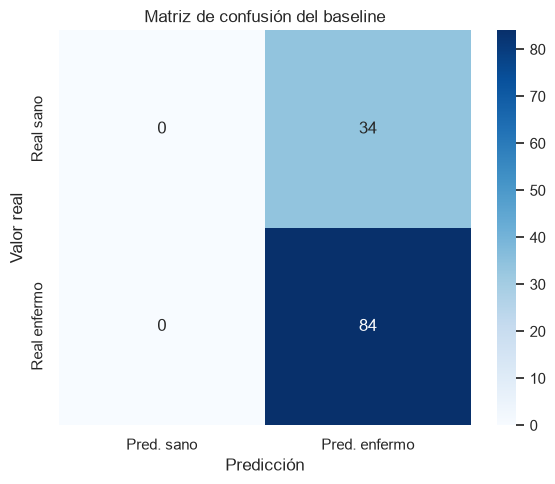

In [6]:
baseline_pipeline = Pipeline(
    steps=[
        ("features", feature_pipeline),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

baseline_pipeline.fit(X_train, y_train)
y_test_pred = baseline_pipeline.predict(X_test)
y_test_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
baseline_metrics = pd.Series(
    {
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "Precision_disease": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall_disease": recall_score(y_test, y_test_pred, zero_division=0),
        "F1_disease": f1_score(y_test, y_test_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_test_proba),
        "Average_precision": average_precision_score(y_test, y_test_proba),
        "Specificity": tn / (tn + fp) if (tn + fp) else 0.0,
    }
).round(4)
display(baseline_metrics.to_frame("Test_value"))

print("Reporte de clasificación:")
print(
    classification_report(
        y_test, y_test_pred, target_names=["Sin enfermedad", "Enfermedad"], zero_division=0
    )
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred, labels=[0, 1]),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred. sano", "Pred. enfermo"],
    yticklabels=["Real sano", "Real enfermo"],
)
plt.title("Matriz de confusión del baseline")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

## 6. Variable candidata y limitación del modelo dummy

El modelo dummy no tiene `feature_importances_` ni coeficientes: no utiliza ninguna variable. Para cumplir el análisis solicitado sin contaminar el test, se calcula un ranking exploratorio de asociación usando únicamente `X_train` y `y_train`. Este ranking no representa importancia causal ni selección definitiva de atributos.

In [7]:
train_numeric = X_train.select_dtypes(include="number").copy()
train_numeric["target"] = y_train
train_association = (
    train_numeric.corr(numeric_only=True)["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
    .rename("Absolute_train_correlation")
    .to_frame()
)
display(train_association.round(4))
candidate_feature = train_association.index[0]
print(f"Variable candidata por asociación exploratoria en train: {candidate_feature}")
print("No se usa para modificar el baseline; los modelos reales requerirán validación cruzada.")

,Absolute_train_correlation
Direct_Bilirubin,0.2499
Total_Bilirubin,0.2182
Alkaline_Phosphotase,0.1859
Albumin_and_Globulin_Ratio,0.1703
Alamine_Aminotransferase,0.1681
Aspartate_Aminotransferase,0.1565
Albumin,0.1467
Age,0.1368
Total_Protiens,0.0232


Variable candidata por asociación exploratoria en train: Direct_Bilirubin
No se usa para modificar el baseline; los modelos reales requerirán validación cruzada.


## 7. Validación cruzada estratificada

La validación cruzada se realiza exclusivamente sobre `X_train`. Cada partición ajusta una copia completa del pipeline, por lo que el conjunto de validación de cada fold no participa en la imputación ni en el escalado.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1,
)

cv_summary = pd.DataFrame(
    {
        "Metric": list(scoring),
        "Mean": [cv_results[f"test_{metric}"].mean() for metric in scoring],
        "Std": [cv_results[f"test_{metric}"].std() for metric in scoring],
    }
).round(4)
display(cv_summary)

,Metric,Mean,Std
0,accuracy,0.7085,0.0052
1,balanced_accuracy,0.5000,0.0000
2,precision,0.7085,0.0052
3,recall,1.0000,0.0000
4,f1,0.8294,0.0036
5,roc_auc,0.5000,0.0000
6,average_precision,0.7085,0.0052


## 8. Learning curve y escalabilidad

Se utiliza `balanced_accuracy` porque la accuracy simple puede ocultar el comportamiento de una clase minoritaria. `return_times=True` permite observar simultáneamente el score y el tiempo de ajuste.

,Train_size,Train_score_mean,Validation_score_mean,Fit_time_mean_seconds
0,75,0.5,0.5,0.1779
1,150,0.5,0.5,0.1829
2,225,0.5,0.5,0.1789
3,300,0.5,0.5,0.1868
4,376,0.5,0.5,0.1826


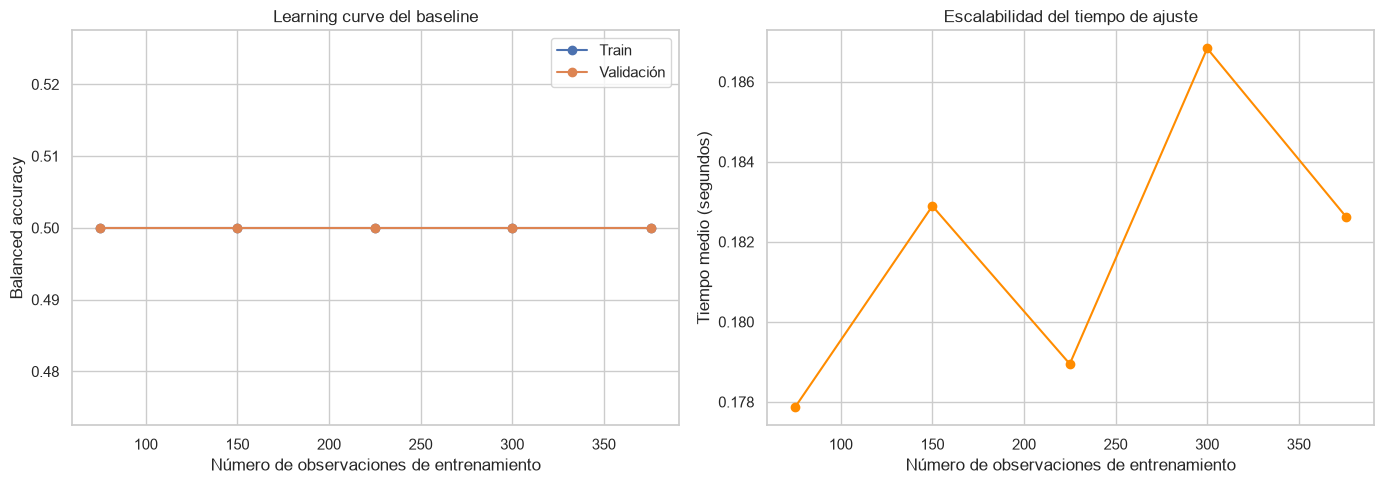

In [9]:
train_sizes, train_scores, validation_scores, fit_times, _ = learning_curve(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="balanced_accuracy",
    return_times=True,
    n_jobs=-1,
)

learning_summary = pd.DataFrame(
    {
        "Train_size": train_sizes,
        "Train_score_mean": train_scores.mean(axis=1),
        "Validation_score_mean": validation_scores.mean(axis=1),
        "Fit_time_mean_seconds": fit_times.mean(axis=1),
    }
).round(4)
display(learning_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
axes[0].plot(train_sizes, validation_scores.mean(axis=1), marker="o", label="Validación")
axes[0].set_title("Learning curve del baseline")
axes[0].set_xlabel("Número de observaciones de entrenamiento")
axes[0].set_ylabel("Balanced accuracy")
axes[0].legend()

axes[1].plot(train_sizes, fit_times.mean(axis=1), marker="o", color="darkorange")
axes[1].set_title("Escalabilidad del tiempo de ajuste")
axes[1].set_xlabel("Número de observaciones de entrenamiento")
axes[1].set_ylabel("Tiempo medio (segundos)")

plt.tight_layout()
plt.show()

## 9. Interpretación, conclusiones y recomendaciones

- `DummyClassifier` establece el rendimiento mínimo de referencia y no aprende relaciones entre las pruebas clínicas y el diagnóstico.
- La accuracy no debe interpretarse de forma aislada: por el desbalance observado, un modelo que predice siempre la clase mayoritaria puede obtener una accuracy aparentemente alta y, aun así, tener balanced accuracy cercana a 0.5.
- Recall, F1, ROC-AUC, average precision y la matriz de confusión son más informativos para comparar modelos en este problema médico.
- El ranking calculado con train solo propone variables candidatas; no constituye importancia de modelo. El baseline no permite seleccionar una variable importante porque ignora todas las características.
- Un modelo posterior debe utilizar el mismo pipeline, superar el baseline en validación cruzada y demostrar mejora también en el test reservado.
- Las siguientes alternativas pueden evaluarse sin añadir librerías: regresión logística, árboles de decisión, Random Forest y Gradient Boosting de scikit-learn.
- La selección de hiperparámetros debe realizarse dentro de validación cruzada sobre train. El test no debe utilizarse para escoger el modelo.
- Antes de considerar un uso clínico serían necesarias validación externa, calibración de probabilidades, análisis de falsos negativos y revisión por expertos.